# Meme Overlay Caption Script

This notebook creates a high-quality meme image overlayed with caption

**Inputs:** 
- Image path (for the moment hardcoded to 0000.jpg from raw humanface)
- Caption string (for the moment hardcoded for testing)

**Output:** 
- High-quality JPG file (256x256) saved in assets folder
- Display in notebook for verification

In [1]:
# Import required libraries
from PIL import Image, ImageDraw, ImageFont
import os
from IPython.display import display

In [2]:
# Configuration
INPUT_IMAGES_DIR = "../assets/raw_humanface"
OUTPUT_IMAGES_DIR = "../assets/memes"
MEME_SIZE = (256, 256)  # Output size to match input

# Hardcoded test caption
TEST_CAPTION_TOP = "HE WAS A LONG TIME"
TEST_CAPTION_BOTTOM = "FRIEND OF MINE"

# Create output directory
os.makedirs(OUTPUT_IMAGES_DIR, exist_ok=True)
print(f"Output directory ready: {OUTPUT_IMAGES_DIR}")

# Use specific first image (0000.jpg)
SELECTED_IMAGE = os.path.join(INPUT_IMAGES_DIR, "0000.jpg")
if not os.path.exists(SELECTED_IMAGE):
    raise ValueError(f"Image {SELECTED_IMAGE} not found. Please run 1a_image_acquisition.ipynb first.")

print(f"Using image: {SELECTED_IMAGE}")

Output directory ready: ../assets/memes
Using image: ../assets/raw_humanface/0000.jpg


In [3]:
def create_meme_direct_pil(image_path, top_text="", bottom_text="", output_path="meme.jpg", size=(256, 256)):
    """
    Create meme directly with PIL for reliable text rendering.
    
    Args:
        image_path (str): Path to input image
        top_text (str): Text for top of meme
        bottom_text (str): Text for bottom of meme  
        output_path (str): Path for output image
        size (tuple): Output image size (width, height)
    
    Returns:
        PIL.Image: The created meme image
    """
    # Load and resize image
    img = Image.open(image_path).convert("RGB")
    img = img.resize(size, Image.Resampling.LANCZOS)

    draw = ImageDraw.Draw(img)
    width, height = img.size

    # Calculate font size based on image size
    font_size = int(width * 0.1)
    outline_width = max(2, font_size // 15)

    # Load font with proper fallbacks
    font = None
    font_paths = [
        "impact.ttf", "Impact.ttf", "IMPACT.TTF",
        "arial.ttf", "Arial.ttf", "arialbd.ttf",
        "/System/Library/Fonts/Impact.ttf",  # macOS
        "/Windows/Fonts/impact.ttf",  # Windows
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf"  # Linux
    ]

    for font_path in font_paths:
        try:
            font = ImageFont.truetype(font_path, size=font_size)
            print(f"Using font: {font_path}")
            break
        except IOError:
            continue

    if font is None:
        font = ImageFont.load_default()
        print("Using default font")

    def draw_meme_text(text, y_position):
        """Helper function to draw outlined text"""
        text = text.upper()
        text_bbox = draw.textbbox((0, 0), text, font=font)
        text_width = text_bbox[2] - text_bbox[0]
        x = (width - text_width) / 2

        # Draw black outline
        for dx in range(-outline_width, outline_width + 1):
            for dy in range(-outline_width, outline_width + 1):
                if dx != 0 or dy != 0:
                    draw.text((x + dx, y_position + dy), text, font=font, fill="black")

        # Draw white text
        draw.text((x, y_position), text, font=font, fill="white")

    # Draw top text
    if top_text:
        draw_meme_text(top_text, font_size // 2)

    # Draw bottom text
    if bottom_text:
        text_bbox = draw.textbbox((0, 0), bottom_text.upper(), font=font)
        text_height = text_bbox[3] - text_bbox[1]
        draw_meme_text(bottom_text, height - text_height - font_size // 2)

    # Save with high quality
    img.save(output_path, "JPEG", quality=98, optimize=True)
    print(f"Meme created and saved: {output_path}")
    return img

In [4]:
# Create meme using direct PIL method
print(f"Creating meme from: {SELECTED_IMAGE}")
print(f"Top text: '{TEST_CAPTION_TOP}'")
print(f"Bottom text: '{TEST_CAPTION_BOTTOM}'")
print(f"Output size: {MEME_SIZE}")

# Execute meme creation
output_filename = "meme.jpg"
output_path = os.path.join(OUTPUT_IMAGES_DIR, output_filename)

meme_image = create_meme_direct_pil(
    image_path=SELECTED_IMAGE,
    top_text=TEST_CAPTION_TOP,
    bottom_text=TEST_CAPTION_BOTTOM,
    output_path=output_path,
    size=MEME_SIZE
)

Creating meme from: ../assets/raw_humanface/0000.jpg
Top text: 'HE WAS A LONG TIME'
Bottom text: 'FRIEND OF MINE'
Output size: (256, 256)
Using font: Impact.ttf
Meme created and saved: ../assets/memes/meme.jpg


Generated Meme:


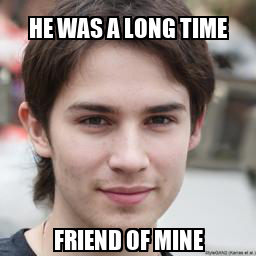


Verification:
File saved at: ../assets/memes/meme.jpg
File exists: True
File size: 22,541 bytes (22.0 KB)
Image dimensions: (256, 256)
Image format: JPEG
Image mode: RGB

Meme saved in: ../assets/memes


In [5]:
# Display the created meme
print("Generated Meme:")
display(meme_image)

# Verification
print(f"\nVerification:")
print(f"File saved at: {output_path}")
print(f"File exists: {os.path.exists(output_path)}")
if os.path.exists(output_path):
    file_size = os.path.getsize(output_path)
    print(f"File size: {file_size:,} bytes ({file_size/1024:.1f} KB)")
    
    # Verify image properties
    verify_img = Image.open(output_path)
    print(f"Image dimensions: {verify_img.size}")
    print(f"Image format: {verify_img.format}")
    print(f"Image mode: {verify_img.mode}")

print(f"\nMeme saved in: {OUTPUT_IMAGES_DIR}")